In [1]:
import numpy as np
import torch
from scipy.linalg import eigh
import networkx as nx
from node2vec import Node2Vec
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
import re

# Processing data

In [2]:
def read_cora_content(file_path):
    # Initialize an empty list to store the data
    data = []

    # Open the file and read line by line
    with open(file_path, 'r') as file:
        for line in file:
            # Strip any leading/trailing whitespace and split the line by spaces
            parts = line.strip().split()
            
            # Extract the unique string ID (first entry)
            paper_id = int(parts[0])
            
            # Extract the binary values (all entries except the first and the last)
            binary_values = list(map(int, parts[1:-1]))
            
            # Extract the class label (last entry)
            label = parts[-1]
            
            # Append the extracted data as a dictionary to the list
            data.append({
                'paper_id': paper_id,
                'binary_values': binary_values,
                'label': label
            })
    
    # Convert the list of dictionaries to a pandas DataFrame for easier manipulation
    df = pd.DataFrame(data)
    df.set_index('paper_id', inplace=True)
    return df

# Example usage
cora_content = read_cora_content("./datasets/cora/cora.content")

In [3]:
def sample_private_nodes(adj_matrix, private_ratio=0.1):

    # sample a number of private nodes
    num_nodes = adj_matrix.shape[0]

    num_private_nodes = int(num_nodes * private_ratio)

    while True:
        g_copy = nx.Graph(adj_matrix)
        private_nodes = np.random.choice(num_nodes, num_private_nodes, replace=False)
        private_edges = list(g_copy.subgraph(private_nodes).edges())
        # remove private edges
        g_copy.remove_edges_from(private_edges)
        # if isolated nodes exist, remove them
        isolate_nodes = list(nx.isolates(g_copy))

        if len(isolate_nodes) == 0:
            print('no isolated nodes')
            private_edges = np.array(private_edges)
            num_private_edges = private_edges.shape[0]
            private_non_edges = []
            G_private = nx.Graph()
            G_private.add_edges_from(private_edges)
            while len(private_non_edges) < num_private_edges:
                u, v = np.random.choice(private_nodes, 2, replace=False)
                if G_private.has_edge(u, v):
                    continue
                elif [u, v] in private_non_edges:
                    continue
                elif [v, u] in private_non_edges:
                    continue
                else:
                    private_non_edges.append([u, v])
            adj_matrix = nx.to_numpy_array(g_copy) # edited
            private_edges = np.array(private_edges)
            private_non_edges = np.array(private_non_edges)
            break
        else:
            print("isolated nodes exist. re-sample.")
            continue

    return adj_matrix, private_edges, private_non_edges, g_copy


In [4]:
G = nx.read_edgelist("./datasets/cora/cora.cites", nodetype=int)
np.random.seed(1)
A, pos_edges, neg_edges, sub_G = sample_private_nodes(nx.to_numpy_array(G))

isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
isolated nodes exist. re-sample.
no isolated nodes


# Evaluation Utils

In [37]:
def evaluate(X, test_edges, test_edges_false):
    X_normalized = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-10)
    scores_matrix = X_normalized.dot(X_normalized.T)
    roc_score, ap_score = get_roc_score(test_edges, test_edges_false, scores_matrix)
    return roc_score, ap_score

def get_roc_score(edges_pos, edges_neg, score_matrix, apply_sigmoid=False):

    # Edge case
    if len(edges_pos) == 0 or len(edges_neg) == 0:
        return (None, None, None)

    # Store positive edge predictions, actual values
    preds_pos = []
    pos = []
    for edge in edges_pos:
        if apply_sigmoid == True:
            preds_pos.append(sigmoid(score_matrix[edge[0], edge[1]]))
        else:
            preds_pos.append(score_matrix[edge[0], edge[1]])
        pos.append(1) # actual value (1 for positive)
        
    # Store negative edge predictions, actual values
    preds_neg = []
    neg = []
    for edge in edges_neg:
        if apply_sigmoid == True:
            preds_neg.append(sigmoid(score_matrix[edge[0], edge[1]]))
        else:
            preds_neg.append(score_matrix[edge[0], edge[1]])
        neg.append(0) # actual value (0 for negative)
        
    # Calculate scores
    preds_all = np.hstack([preds_pos, preds_neg])
    labels_all = np.hstack([np.ones(len(preds_pos)), np.zeros(len(preds_neg))])
    roc_score = roc_auc_score(labels_all, preds_all)
    # roc_curve_tuple = roc_curve(labels_all, preds_all)
    ap_score = average_precision_score(labels_all, preds_all)
    
    # return roc_score, roc_curve_tuple, ap_score
    return roc_score, ap_score

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [6]:
def evaluate_embedding_node_classification(embedding_matrix, labels, train_ratio=0.7, norm=True, seed=0, n_repeats=20):
    """Evaluate the node embeddings on the node classification task..

    :param embedding_matrix: np.ndarray, shape [n_nodes, embedding_dim]
        Embedding matrix
    :param labels: np.ndarray, shape [n_nodes]
        The ground truth labels
    :param train_ratio: float
        The fraction of labels to use for training
    :param norm: bool
        Whether to normalize the embeddings
    :param seed: int
        Random seed
    :param n_repeats: int
        Number of times to repeat the experiment
    :return: [float, float], [float, float]
        The mean and standard deviation of the f1_scores
    """
    if norm:
        embedding_matrix = normalize(embedding_matrix)

    results = []
    accs = []
    for it_seed in range(n_repeats):
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - train_ratio, random_state=seed + it_seed)
        split_train, split_test = next(sss.split(embedding_matrix, labels))
        
        features_train = embedding_matrix[split_train]
        features_test = embedding_matrix[split_test]
        labels_train = labels[split_train]
        labels_test = labels[split_test]
        lr = LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='auto')
        lr.fit(features_train, labels_train)

        lr_z_predict = lr.predict(features_test)
        f1_micro = f1_score(labels_test, lr_z_predict, average='micro')
        f1_macro = f1_score(labels_test, lr_z_predict, average='macro')

        acc = accuracy_score(labels_test, lr_z_predict)

        results.append([f1_micro, f1_macro])
        accs.append(acc)

    results = np.array(results)
    accs = np.array(accs)
    
    return results.mean(0), results.std(0), np.mean(accs)

# PPNE

In [13]:
def MF_deep_walk(A, walk_length, negative_samples_size, embedding_dim):
    vol_A = torch.sum(A)
    D_inversed = torch.diag(torch.sum(A, dim=1)**-1)
    
    sum_matrix = torch.zeros(A.shape).double()
    power_matrix = torch.eye(A.shape[0]).double()
    base_matrix = D_inversed @ A
    for _ in range(walk_length):
        power_matrix = power_matrix @ base_matrix
        sum_matrix += power_matrix

    Z = (vol_A/(walk_length*negative_samples_size)) * sum_matrix @ D_inversed
    Z = torch.log(torch.clamp(Z, 1))
    
    U, S, Vh = torch.linalg.svd(Z, full_matrices=False)

    X = U[:, :embedding_dim] @ torch.sqrt(torch.diag(S[:embedding_dim]))
    Y = (torch.sqrt(torch.diag(S[:embedding_dim])) @ Vh[:embedding_dim,:]).T 
    return X, Y, Z

In [8]:
def calculate_grad_Z(X, Y, Z, X_grad):
    n, d = X.shape
    Omega = (Z != -float('inf'))
    grad_Z = torch.zeros((n,n)).double()
    for i in range(n):
        if torch.nonzero(X_grad[i]).numel() == 0: 
            # if the ith node is not used to calculate privacy loss, its embeddings has 0 gradients
            # this if statement is to avoid calculating the gradient of Z for this node and speed up the computation
            continue

        # calculating grad_Z, a matrix of size n x n containing 
        # the gradient of each Zij w.r.t. each Xij of the ith row of X
        # the rows are for the Xij, the cols are for the Zij
        Omega_i = np.argwhere(Omega[i])[0]
        y_yt_sum = torch.zeros((d,d)).double()
    
        for j in Omega_i:
            y = Y[j].reshape(1,-1)
            y_yt_sum += torch.mm(torch.t(y),y)

        y_yt_sum_inv = torch.linalg.inv(y_yt_sum)
        
        grad_Z[i] = torch.mm(X_grad[i].reshape(1,-1), torch.mm(y_yt_sum_inv, Y.t()))[0]

    return grad_Z

In [9]:
def privacy_loss(X, pos_edges, neg_edges):
    cosine_similarities = X @ X.T

    i_s, j_s = np.array(pos_edges).T
    pos_similarities = torch.sum(cosine_similarities[i_s, j_s])

    i_s, j_s = np.array(neg_edges).T
    neg_similarities = torch.sum(cosine_similarities[i_s, j_s])

    return pos_similarities - neg_similarities

In [10]:
def proxy_utility_loss(A, delta, walk_length, negative_samples_size, embedding_dim):
    
    # calculating sigma_p
    degrees = np.sum(A, axis=1)
    D = np.diag(degrees)
    generalized_eigh_values, _ = eigh(A, D)
    generalized_eigh_values = generalized_eigh_values[0:A.shape[0]-embedding_dim] # get |V| - K lowest eigenvalues 

    eigenvalue_power_sum = np.zeros(len(generalized_eigh_values))
    for r in range(walk_length):
        eigenvalue_power_sum += np.power(generalized_eigh_values, r+1)
    
    
    d_min = np.min(degrees)
    sigma_p = (1/d_min) * np.abs(eigenvalue_power_sum)

    # calculating the final outputs
    vol_A = np.sum(A)
    output = ((vol_A + 2*delta)/(walk_length*negative_samples_size)) * np.sqrt(np.sum(np.power(sigma_p, 2)))
    
    return output

In [ ]:
def PPNE(A, sampling_size, batching_size, n_iterations, walk_length, negative_samples_size, embedding_dim, pos_edges, neg_edges, k, verbose=False, eval=False, labels=None):
    
    A_perturbed = A.copy()
    delta = (A_perturbed == 0) - A_perturbed # change in 1 edge to create candidate perturbations
    current_privacy_gain = 0
    for ITER in range(n_iterations):

        print(f"Iteration {ITER+1}/{n_iterations}, now time: {datetime.now().strftime('%H:%M:%S')}")

        ### Opimizing ###
        ### Compute Privacy Gains for all pertubations - using torch
        A_perturbed_torch = torch.tensor(A_perturbed, requires_grad=True).double()
        X, Y, Z = MF_deep_walk(A_perturbed_torch, walk_length, negative_samples_size, embedding_dim)        

        if eval:
            X_numpy = X.detach().numpy()
            roc, ap = evaluate(X_numpy, pos_edges, neg_edges)
            f1_score_mean, _, acc = evaluate_embedding_node_classification(X_numpy, labels)
            print(f"ROC: {roc}, AP: {ap}, micro-f1: {f1_score_mean[0]}, macro-f1: {f1_score_mean[1]}, ACC: {acc}")

        # Calculate X_grad
        # print("Computing X_grad")
        X_detached = X.detach().requires_grad_(True)
        pl = privacy_loss(X_detached, pos_edges, neg_edges)
        pl.backward()

        # Calculate Z_grad
        # print("Computing Z_grad")
        with torch.no_grad():
            Z_grad = calculate_grad_Z(X, Y, Z, X_detached.grad)

        # Calculate A_grad
        # print("Computing A_grad")
        loss = (Z_grad * Z).sum()
        loss.backward()

        # Calculate privacy gain and clean up
        perturbation_privacy_gains = current_privacy_gain - A_perturbed_torch.grad.numpy() * delta
        X_detached.grad.zero_()
        A_perturbed_torch.grad.zero_()

        ### Compute Utility Loss for all pertubations - using numpy
        # print("Computing Utility Loss")
        perturbation_utility_losses = proxy_utility_loss(A_perturbed, delta, walk_length, negative_samples_size, embedding_dim)

        ### Get the best perturbation
        scores = perturbation_privacy_gains / (perturbation_utility_losses + 1)**k
        scores = scores + np.eye(scores.shape[0]) * -1e10 # exclude self edges
        idx = np.argmax(scores)
        row = idx // scores.shape[0]
        col = idx % scores.shape[0]

        ### Update the best perturbation
        if verbose:
            if delta[row, col] == 1:
                print(f"Adding edge ({row}, {col})")
            else:
                print(f"Removing edge ({row}, {col})")

        A_perturbed[row, col] = A_perturbed[row, col] + delta[row, col]
        A_perturbed[col, row] = A_perturbed[col, row] + delta[col, row]
        delta[row, col] = delta[row, col] * -1
        delta[col, row] = delta[col, row] * -1
        current_privacy_gain = perturbation_privacy_gains[row,col]
    
    with torch.no_grad():
        X, _, _ = MF_deep_walk(torch.tensor(A_perturbed), walk_length, negative_samples_size, embedding_dim)
        
    return X.numpy(), A_perturbed

# Main

In [73]:
labels = cora_content.loc[list(G.nodes())]['label'].to_numpy()
perturbed_embedding, perturbed_adj = PPNE(A, sampling_size=10000, batching_size=1, n_iterations=1000, 
                                          walk_length=5, negative_samples_size=5, embedding_dim=128, 
                                          pos_edges=pos_edges, neg_edges=neg_edges, k=1, verbose=True, eval=True, labels=labels)


Iteration 1/1000, now time: 16:23:40
ROC: 0.850089232599643, AP: 0.9141790618674561, micro-f1: 0.821709717097171, macro-f1: 0.8126436479801449, ACC: 0.821709717097171
Adding edge (1516, 2472)
Iteration 2/1000, now time: 16:24:02
ROC: 0.8483045806067817, AP: 0.9132558307392614, micro-f1: 0.8214022140221402, macro-f1: 0.8124391207828664, ACC: 0.8214022140221402
Adding edge (547, 1270)
Iteration 3/1000, now time: 16:24:25
ROC: 0.8483045806067816, AP: 0.9116558161496282, micro-f1: 0.8223247232472325, macro-f1: 0.8132603667630296, ACC: 0.8223247232472325
Adding edge (2659, 296)
Iteration 4/1000, now time: 16:24:47
ROC: 0.8441403926234383, AP: 0.9079190785726572, micro-f1: 0.8226322263222633, macro-f1: 0.8134677576652789, ACC: 0.8226322263222633
Adding edge (2659, 1705)
Iteration 5/1000, now time: 16:25:10
ROC: 0.8322427126710292, AP: 0.8858047625078936, micro-f1: 0.8224477244772448, macro-f1: 0.8132363578297145, ACC: 0.8224477244772448
Adding edge (1516, 460)
Iteration 6/1000, now time: 16:

KeyboardInterrupt: 

# Log analysis

In [74]:
with open('./logs/ours/cora_ppne_trade_off/2nd_implementation.txt', 'r') as file:
    log_text = file.read()
    
def parse_log_to_dataframe(log_text):
    # Regular expression to extract metrics from each iteration
    pattern = r"Iteration (\d+)/\d+, now time: .+\nROC: ([\d.]+), AP: ([\d.]+), micro-f1: ([\d.]+), macro-f1: ([\d.]+), ACC: ([\d.]+)"
    
    # Find all matches in the log text
    matches = re.findall(pattern, log_text)
    
    # Create lists for each column
    iterations = []
    roc_values = []
    ap_values = []
    micro_f1_values = []
    macro_f1_values = []
    acc_values = []
    
    # Extract values from matches
    for match in matches:
        iterations.append(int(match[0]))
        roc_values.append(float(match[1]))
        ap_values.append(float(match[2]))
        micro_f1_values.append(float(match[3]))
        macro_f1_values.append(float(match[4]))
        acc_values.append(float(match[5]))
    
    # Create a dictionary with the extracted data
    data = {
        'iteration': iterations,
        'roc': roc_values,
        'ap': ap_values,
        'micro-f1': micro_f1_values,
        'macro-f1': macro_f1_values,
        'acc': acc_values
    }
    
    # Create and return the DataFrame
    return pd.DataFrame(data)

log_df = parse_log_to_dataframe(log_text)
log_df.head()

,iteration,roc,ap,micro-f1,macro-f1,acc
0,1,0.850089,0.914179,0.821710,0.812644,0.821710
1,2,0.848305,0.913256,0.821402,0.812439,0.821402
2,3,0.848305,0.911656,0.822325,0.813260,0.822325
3,4,0.844140,0.907919,0.822632,0.813468,0.822632
4,5,0.832243,0.885805,0.822448,0.813236,0.822448


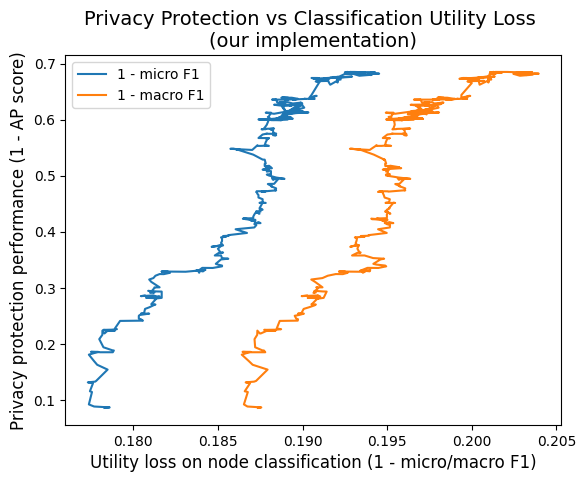

In [75]:
plt.plot(1-log_df['micro-f1'], 1 - log_df['ap'], label = '1 - micro F1')
plt.plot(1-log_df['macro-f1'], 1 - log_df['ap'], label = '1 - macro F1')
plt.title('Privacy Protection vs Classification Utility Loss \n(our implementation)', fontsize=14)
plt.xlabel('Utility loss on node classification (1 - micro/macro F1)', fontsize=12)
plt.ylabel('Privacy protection performance (1 - AP score)', fontsize=12)
plt.legend()
plt.show()

# DeepWalk MF vs original

## Matrix Factorization

In [61]:
X, Y, Z = MF_deep_walk(torch.tensor(A), walk_length=5, negative_samples_size=5, embedding_dim=128)

Explained variance ratio: [0.01325033 0.01266492 0.01259549 0.01246977 0.01221371 0.01165442
 0.01132966 0.01118056 0.01094861 0.01084146 0.01062232 0.01042175
 0.01034866 0.01029621 0.01023114 0.01012615 0.0100737  0.00995898
 0.00989225 0.0098667  0.00982073 0.0097756  0.00975248 0.00960471
 0.00951504 0.00945036 0.00931394 0.00929036 0.0092552  0.00918633
 0.00909996 0.00909025 0.00904235 0.00887632 0.00879619 0.00876856
 0.00871497 0.00862794 0.00861481 0.00850228 0.00846889 0.00840961
 0.00833112 0.00831164 0.00826225 0.00824194 0.00823426 0.0081634
 0.00809068 0.00803308 0.00796744 0.00795591 0.00791879 0.00787674
 0.00783099 0.00780755 0.0077614  0.00773106 0.00769062 0.00763594
 0.00761868 0.00752146 0.0074503  0.00743699 0.00739865 0.00738556
 0.00733387 0.00726349 0.00720074 0.00718936 0.00717058 0.00713062
 0.00710188 0.00703591 0.00701685 0.00699262 0.00693431 0.00688072
 0.00684282 0.00682503 0.0068119  0.00679388 0.006759   0.00671992
 0.00668964 0.00667722 0.00665257 0.0

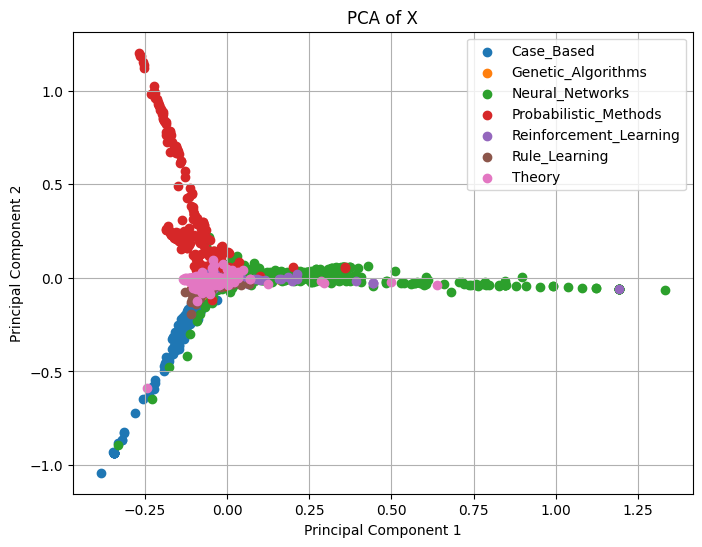

In [62]:
## Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X)

## Combine with class labels
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'label': cora_content.loc[list(G.nodes())]['label']
})

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the first two principal components
plt.figure(figsize=(8, 6))

for label in np.unique(pca_df['label']):
    indices = pca_df['label'] == label
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=label)

plt.title('PCA of X')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

Explained variance ratio: [0.01325033 0.01266492 0.01259549 0.01246977 0.01221371 0.01165442
 0.01132966 0.01118056 0.01094861 0.01084146 0.01062232 0.01042175
 0.01034866 0.01029621 0.01023114 0.01012615 0.0100737  0.00995898
 0.00989225 0.0098667  0.00982073 0.0097756  0.00975248 0.00960471
 0.00951504 0.00945036 0.00931394 0.00929036 0.0092552  0.00918633
 0.00909996 0.00909025 0.00904235 0.00887632 0.00879619 0.00876856
 0.00871497 0.00862794 0.00861481 0.00850228 0.00846889 0.00840961
 0.00833112 0.00831164 0.00826225 0.00824194 0.00823426 0.0081634
 0.00809068 0.00803308 0.00796744 0.00795591 0.00791879 0.00787674
 0.00783099 0.00780755 0.0077614  0.00773106 0.00769062 0.00763594
 0.00761868 0.00752146 0.0074503  0.00743699 0.00739865 0.00738556
 0.00733387 0.00726349 0.00720074 0.00718936 0.00717058 0.00713062
 0.00710188 0.00703591 0.00701685 0.00699262 0.00693431 0.00688072
 0.00684282 0.00682503 0.0068119  0.00679388 0.006759   0.00671992
 0.00668964 0.00667722 0.00665257 0.0

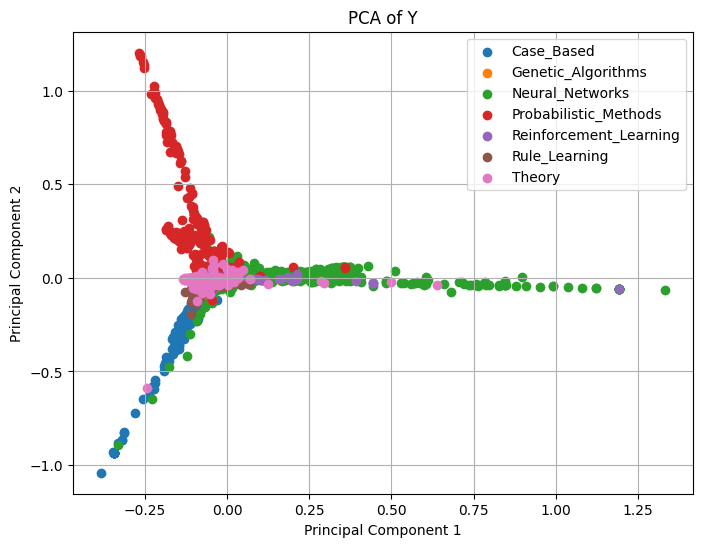

In [63]:
# # Perform PCA
pca = PCA()
Y_pca = pca.fit_transform(Y)

## Combine with class labels
pca_df = pd.DataFrame({
    'PC1': Y_pca[:, 0],
    'PC2': Y_pca[:, 1],
    'label': cora_content.loc[list(G.nodes())]['label']
})

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the first two principal components
plt.figure(figsize=(8, 6))

for label in np.unique(pca_df['label']):
    indices = pca_df['label'] == label
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=label)

plt.title('PCA of Y')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

## Node2Vec implementation

In [64]:
node2vec = Node2Vec(sub_G, dimensions=128, walk_length=100, num_walks=10, workers=1)  # Use temp_folder for big graphs
model = node2vec.fit(window=5, min_count=0, seed=0, sg=1, negative=5, epochs=1, ns_exponent=1)


Computing transition probabilities:   0%|          | 0/2708 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|████████████████| 10/10 [00:07<00:00,  1.32it/s]


In [65]:
emb_X = []
emb_Y = []
key2idx = model.wv.key_to_index
for node_name in sub_G.nodes():
    emb_X.append(model.wv[str(node_name)])
    emb_Y.append(model.syn1neg[key2idx[str(node_name)]])
X_n2v = np.vstack(emb_X)
Y_n2v = np.vstack(emb_Y)

Explained variance ratio: [0.07181325 0.06288236 0.05781756 0.04727468 0.04107707 0.03511659
 0.03065249 0.03012072 0.02811997 0.02581981 0.02458267 0.0234065
 0.02143526 0.02086521 0.02044659 0.0184384  0.01705633 0.01643769
 0.01602835 0.01515694 0.0149236  0.01418486 0.01328145 0.01256154
 0.01217309 0.01181377 0.01136384 0.01098745 0.01046963 0.010165
 0.00990951 0.00905467 0.00901876 0.00864948 0.00842318 0.0080496
 0.00770994 0.00746777 0.00720572 0.00706508 0.00667144 0.00654527
 0.00627401 0.00592772 0.00578982 0.00556228 0.00538874 0.00526439
 0.00509173 0.00487331 0.00471138 0.00454802 0.00444257 0.00413946
 0.00393565 0.00378583 0.0036211  0.00346431 0.00336055 0.00324731
 0.00318066 0.00293684 0.00279856 0.00273834 0.0026536  0.00253425
 0.00249437 0.00229296 0.00226656 0.00217418 0.00214714 0.00198911
 0.00196013 0.00188877 0.001839   0.00180553 0.00172551 0.00165598
 0.00155271 0.00146656 0.00143372 0.00140794 0.00132522 0.00126445
 0.00124741 0.00117266 0.00111572 0.0010

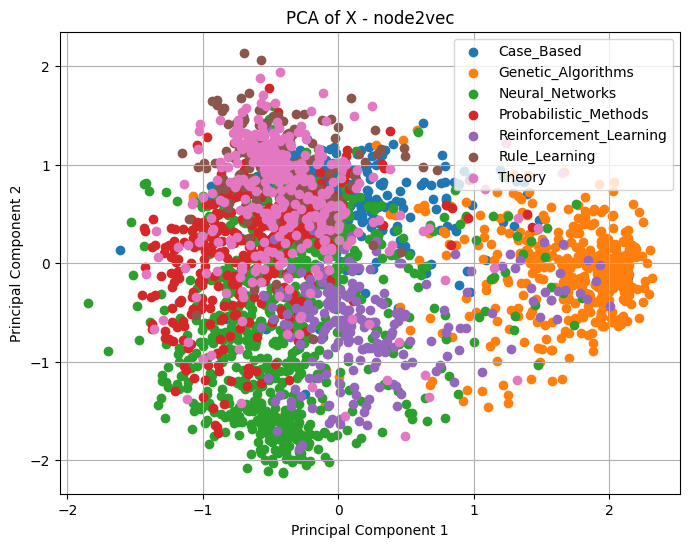

In [66]:
## Perform PCA
pca = PCA()
X_n2v_pca = pca.fit_transform(X_n2v)

## Combine with class labels
pca_df = pd.DataFrame({
    'PC1': X_n2v_pca[:, 0],
    'PC2': X_n2v_pca[:, 1],
    'label': cora_content.loc[list(G.nodes())]['label']
})

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the first two principal components
plt.figure(figsize=(8, 6))

for label in np.unique(pca_df['label']):
    indices = pca_df['label'] == label
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=label)

plt.title('PCA of X - node2vec')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

Explained variance ratio: [0.07371708 0.06356793 0.05814882 0.04793946 0.04114125 0.03528409
 0.03051551 0.03008765 0.02803719 0.02581066 0.02451861 0.02334137
 0.02141768 0.0208299  0.02041099 0.01839157 0.01699026 0.01641122
 0.01598433 0.01509803 0.01489407 0.01411539 0.01321433 0.01251502
 0.01214121 0.01175699 0.01131918 0.01095983 0.01045397 0.01016126
 0.00988423 0.00902109 0.00894813 0.00858615 0.00832518 0.00800807
 0.00772376 0.00741577 0.00716058 0.00703787 0.00663898 0.00650823
 0.00621096 0.00592295 0.00574415 0.00555301 0.00530326 0.00514849
 0.00486809 0.00469113 0.00464119 0.00444534 0.00425841 0.00396692
 0.00386108 0.00374211 0.00354079 0.0034546  0.00334023 0.00321953
 0.00313442 0.00291399 0.00276643 0.00271959 0.00265536 0.00249531
 0.00247628 0.00227323 0.00226047 0.00216786 0.00214006 0.00198363
 0.00195623 0.00186874 0.00180574 0.00177658 0.00171949 0.00164827
 0.00153225 0.00145059 0.00142168 0.00138352 0.00131668 0.00123879
 0.00122096 0.00116348 0.00111158 0.

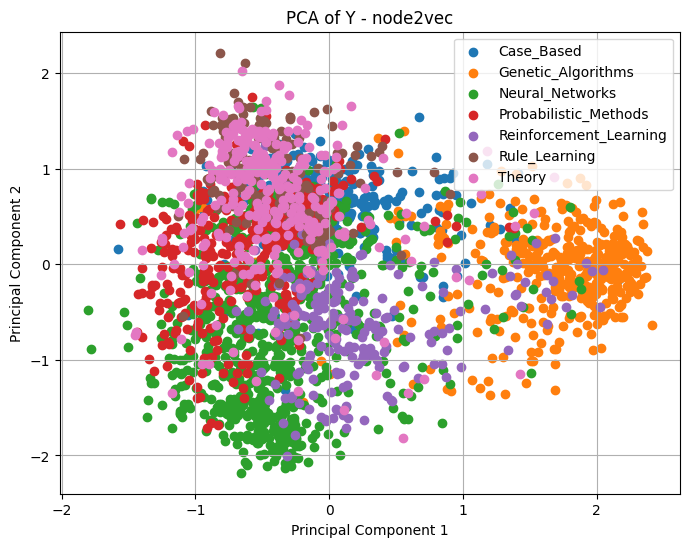

In [67]:
pca = PCA()
Y_n2v_pca = pca.fit_transform(Y_n2v)

## Combine with class labels
pca_df = pd.DataFrame({
    'PC1': Y_n2v_pca[:, 0],
    'PC2': Y_n2v_pca[:, 1],
    'label': cora_content.loc[list(G.nodes())]['label']
})

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the first two principal components
plt.figure(figsize=(8, 6))

for label in np.unique(pca_df['label']):
    indices = pca_df['label'] == label
    plt.scatter(pca_df.loc[indices, 'PC1'], pca_df.loc[indices, 'PC2'], label=label)

plt.title('PCA of Y - node2vec')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

## Evaluating both methods

In [68]:
print('ROC/AP for test edges')
print(evaluate(X.numpy(), pos_edges, neg_edges))
print(evaluate(X_n2v, pos_edges, neg_edges))

print('Node classification for all nodes - micro/macro f1')
labels = cora_content.loc[list(G.nodes())]['label'].to_numpy()
f1_score_mean, _, acc = evaluate_embedding_node_classification(X.numpy(), labels)
print(f1_score_mean)

labels = cora_content.loc[list(G.nodes())]['label'].to_numpy()
f1_score_mean, _, acc = evaluate_embedding_node_classification(X_n2v, labels)
print(f1_score_mean)

ROC/AP for test edges
(0.850089232599643, 0.9141790618674561)
(0.916716240333135, 0.9416121287077446)
Node classification for all nodes - micro/macro f1
[0.82170972 0.81264365]
[0.80725707 0.79970785]
